In [1]:
import numpy as np
import scanpy as sc
import seaborn as sns
import shutil
import sys
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import celltypist
import pandas as pd
import pandas.core.indexes.base as pandas_indexes_base
import scvi
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation
from rpy2.robjects import packages as rpackages
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
from scipy.sparse import csr_matrix, issparse
from pathlib import Path
from cellmapper import CellMapper
from celltypist import models

import streamlit as st
import tempfile
import os

r = ro.r
rcb.logger.setLevel(logging.ERROR)
sc.settings.verbosity = 0
sc.set_figure_params(dpi=80, facecolor='white', frameon=False)

%load_ext rpy2.ipython

/home/farshid/miniconda/envs/pyroe_env/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
# REMOVE them after finalizing
adata = sc.read_10x_h5('filtered_feature_bc_matrix.h5')
adata_raw = sc.read_10x_h5('raw_feature_bc_matrix.h5')

# # keys: cell types or populations, values: lists of marker genes
# marker_genes = {
#     "CD14+ Mono": ["FCN1", "CD14"],
#     "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
#     "ID2-hi myeloid prog": [
#         "CD14",
#         "ID2",
#         "VCAN",
#         "S100A9",
#         "CLEC12A",
#         "KLF4",
#         "PLAUR",
#     ],
#     "cDC1": ["CLEC9A", "CADM1"],
#     "cDC2": [
#         "CST3",
#         "COTL1",
#         "LYZ",
#         "DMXL2",
#         "CLEC10A",
#         "FCER1A",
#     ],  # Note: DMXL2 should be negative
#     "Normoblast": ["SLC4A1", "SLC25A37", "HBB", "HBA2", "HBA1", "TFRC"],
#     "Erythroblast": ["MKI67", "HBA1", "HBB"],
#     "Proerythroblast": [
#         "CDK6",
#         "SYNGR1",
#         "HBM",
#         "GYPA",
#     ],  # Note HBM and GYPA are negative markers
#     "NK": ["GNLY", "NKG7", "CD247", "GRIK4", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
#     "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
#     "Lymph prog": [
#         "VPREB1",
#         "MME",
#         "EBF1",
#         "SSBP2",
#         "BACH2",
#         "CD79B",
#         "IGHM",
#         "PAX5",
#         "PRKCE",
#         "DNTT",
#         "IGLL1",
#     ],
#     "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
#     "B1 B": [
#         "MS4A1",
#         "SSPN",
#         "ITGB1",
#         "EPHA4",
#         "COL4A4",
#         "PRDM1",
#         "IRF4",
#         "CD38",
#         "XBP1",
#         "PAX5",
#         "BCL11A",
#         "BLK",
#         "IGHD",
#         "IGHM",
#         "ZNF215",
#     ],  # Note IGHD and IGHM are negative markers
#     "Transitional B": ["MME", "CD38", "CD24", "ACSM3", "MSI2"],
#     "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
#     "Plasmablast": ["XBP1", "RF4", "PRDM1", "PAX5"],  # Note PAX5 is a negative marker
#     "CD4+ T activated": ["CD4", "IL7R", "TRBC2", "ITGB1"],
#     "CD4+ T naive": ["CD4", "IL7R", "TRBC2", "CCR7"],
#     "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
#     "T activation": ["CD69", "CD38"],  # CD69 much better marker!
#     "T naive": ["LEF1", "CCR7", "TCF7"],
#     "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
#     "G/M prog": ["MPO", "BCL2", "KCNQ5", "CSF3R"],
#     "HSC": ["NRIP1", "MECOM", "PROM1", "NKAIN2", "CD34"],
#     "MK/E prog": [
#         "ZNF385D",
#         "ITGA2B",
#         "RYR3",
#         "PLCB1",
#     ],  # Note PLCB1 is a negative marker
# }

# methods

In [3]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
    np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

def filter_cells_by_mad(
    adata,
    mt_prefix,
    ribo_prefix,
    hb_prefix=r"^HB[^P]",
    top_gene_per=20,
    general_MAD=5,
    mt_MAD=3,
    mt_threshold=8
):
    '''
    Filter low-quality cells using Median Absolute Deviation (MAD).
    
    This function:
    - Calculates QC metrics for mitochondrial, ribosomal, and hemoglobin genes.
    - Detects outlier cells based on total counts, detected genes, and highly expressed genes.
    - Detects cells with abnormal or high mitochondrial content.
    - Removes the identified low-quality cells.
    - Returns the filtered AnnData object.
    '''   
    adata.var_names_make_unique()
    
    # 1- QC stage
    adata.var["mt"] = adata.var_names.str.startswith(mt_prefix)
    adata.var["ribo"] = adata.var_names.str.startswith(ribo_prefix)
    adata.var["hb"] = adata.var_names.str.contains(hb_prefix,regex=True)

    sc.pp.calculate_qc_metrics(adata,
                               qc_vars=["mt", "ribo", "hb"],
                               percent_top=[top_gene_per],
                               log1p=True,
                               inplace=True)
    # 2- Detects outlier cells
    adata.obs['outlier'] = (is_outlier(adata, 'log1p_total_counts', general_MAD) |
                        is_outlier(adata, 'log1p_n_genes_by_counts', general_MAD) |
                        is_outlier(adata, f'pct_counts_in_top_{top_gene_per}_genes', general_MAD))

    # 3- Detects cells with abnormal or high mitochondrial content
    adata.obs['mt_outlier'] = is_outlier(adata, 'pct_counts_mt', mt_MAD)| (adata.obs["pct_counts_mt"] > mt_threshold)

    n_cells_before_filtering = adata.n_obs

    # 4- Filtering...
    adata = adata[(~adata.obs["outlier"]) & (~adata.obs["mt_outlier"])].copy()

    n_cells_filtered = n_cells_before_filtering - adata.n_obs
    
    return adata, n_cells_filtered

def remove_ambient_rna_soupx(adata,
                     raw_matrix=None):
    '''
    Remove ambient RNA contamination using SoupX.

    This function:
    - Uses the raw and filtered count matrices.
    - Generates temporary cell clusters required by SoupX.
    - Estimates the ambient RNA contamination fraction.
    - Corrects gene expression counts.
    - Stores original and corrected counts in AnnData layers.
    - Returns the SoupX-corrected AnnData object.
    '''
    
    adata_raw = raw_matrix.copy()
    adata_raw.var_names_make_unique()
    
    if not adata.var_names.equals(adata_raw.var_names):
        raise ValueError("Gene names/order differ between filtered and raw matrices.")
    
    data_tod = adata_raw.X.T
    tod_cells = adata_raw.obs_names
    
    del adata_raw
      
    SoupX = importr("SoupX")
    adata_pp = adata.copy()
    sc.pp.normalize_total(adata_pp)
    sc.pp.log1p(adata_pp)
    sc.pp.pca(adata_pp)
    sc.pp.neighbors(adata_pp)
    sc.tl.leiden(adata_pp,key_added="soupx_groups")
    soupx_groups = adata_pp.obs["soupx_groups"]

    del adata_pp
    
    cells = adata.obs_names
    genes = adata.var_names
    data = adata.X.T

    with localconverter(
        ro.default_converter +
        pandas2ri.converter +
        anndata2ri.converter
    ):
        ro.globalenv["data"] = data
        ro.globalenv["data_tod"] = data_tod
        ro.globalenv["genes"] = genes.to_numpy()
        ro.globalenv["cells"] = cells.to_numpy()
        ro.globalenv["tod_cells"] = tod_cells.to_numpy()
        ro.globalenv["soupx_groups"] = soupx_groups.astype(str)
        
    # Run SoupX in R
    r("""
        rownames(data) <- genes
        colnames(data) <- cells
        
        rownames(data_tod) <- genes
        colnames(data_tod) <- tod_cells
        
        data <- as(data, "sparseMatrix")
        data_tod <- as(data_tod, "sparseMatrix")
        
        # Create SoupChannel and automatically estimate soup profile
        sc <- SoupChannel(
            data_tod,
            data,
            calcSoupProfile=TRUE
        )
        
        # Add cluster information
        sc <- setClusters(sc, soupx_groups)
        
        # Estimate contamination fraction
        sc <- autoEstCont(sc, doPlot=FALSE)
        
        # Correct counts
        out <- adjustCounts(sc, roundToInt=TRUE)
    """)
    with localconverter(
    ro.default_converter +
    pandas2ri.converter +
    anndata2ri.converter
    ):    
        out = ro.conversion.get_conversion().rpy2py(ro.globalenv["out"])

    # Store original counts
    adata.layers["counts"] = adata.X.copy()

    # Store SoupX-corrected counts
    adata.layers["soupx_counts"] = out.T
    
    # Continue downstream analysis using SoupX-corrected counts
    adata.X = adata.layers["soupx_counts"].copy()

    return adata

def detect_doublets(adata, remove=False):
    '''
    Detect doublets using scDblFinder or Scrublet and optionally remove them.

    Parameters
    ----------
    adata : AnnData
        AnnData object containing raw counts in adata.X.

    remove : bool, default=False
        If True, detected doublets are removed.
        If False, doublets are only annotated.

    Returns
    -------
    adata : AnnData
        AnnData with doublet scores and classifications.

    n_cells_before_doublet_filtering : int
        Number of cells before doublet filtering.
    '''

    n_cells_before_doublet_filtering = adata.n_obs

    Seurat = importr("Seurat")
    scater = importr("scater")
    scDblFinder = importr("scDblFinder")
    BiocParallel = importr("BiocParallel")

    data_mat = adata.X.T

    with localconverter(
        ro.default_converter
        + pandas2ri.converter
        + anndata2ri.converter
    ):
        ro.globalenv["data_mat"] = data_mat

    r("""
        set.seed(123)

        sce <- SingleCellExperiment(list(counts=data_mat))
        sce <- scDblFinder(sce)

        doublet_score <- sce$scDblFinder.score
        doublet_class <- as.character(sce$scDblFinder.class)
    """)

    doublet_score = np.asarray(
        ro.globalenv["doublet_score"]
    )

    doublet_class = np.asarray(
        ro.globalenv["doublet_class"]
    )

    adata.obs["doublet_score"] = doublet_score
    adata.obs["doublet_class"] = doublet_class
    n_doublets = int((adata.obs["doublet_class"] == "doublet").sum())

    if remove:
        adata = adata[
            adata.obs["doublet_class"] == "singlet"
        ].copy()
        
    return adata, n_doublets


def detect_doublets(adata, remove=False):
    '''
    Detect doublets using scDblFinder or Scrublet and optionally remove them.

    Parameters
    ----------
    adata : AnnData
        AnnData object containing raw counts in adata.X.

    remove : bool, default=False
        If True, detected doublets are removed.
        If False, doublets are only annotated.

    Returns
    -------
    adata : AnnData
        AnnData with doublet scores and classifications.

    n_cells_before_doublet_filtering : int
        Number of cells before doublet filtering.
    '''
    conversion.set_conversion(ro.default_converter)
    
    # adata = adata.copy()

    n_cells_before_doublet_filtering = adata.n_obs

    SingleCellExperiment = importr("SingleCellExperiment")
    scDblFinder = importr("scDblFinder")

    with localconverter(
        ro.default_converter
        + pandas2ri.converter
        + anndata2ri.converter
    ):
        ro.globalenv["data_mat"] = data_mat

    r("""
        set.seed(123)

        sce <- SingleCellExperiment(list(counts=data_mat))
        sce <- scDblFinder(sce)

        doublet_score <- sce$scDblFinder.score
        doublet_class <- as.character(sce$scDblFinder.class)
    """)

    doublet_score = np.asarray(
        ro.globalenv["doublet_score"]
    )

    doublet_class = np.asarray(
        ro.globalenv["doublet_class"]
    )

    adata.obs["doublet_score"] = doublet_score
    adata.obs["doublet_class"] = doublet_class
    n_doublets = (adata.obs["doublet_class"] == "doublet").sum()

    if remove:
        adata = adata[
            adata.obs["doublet_class"] == "singlet"
        ].copy()
        
    return adata, n_doublets




def filter_genes_by_min_cells(adata, min_cells):
    '''
    Filter genes based on the minimum number of cells.

    This function:
    - Removes genes detected in fewer than `min_cells` cells.
    - Removes low-information genes from downstream analysis.
    - Returns the filtered AnnData object and the number of genes before filtering.
    '''
    
    adata = adata.copy()
    n_genes_before_filtering = adata.n_vars
    sc.pp.filter_genes(adata,min_cells=min_cells)
    
    n_genes_filtered = n_genes_before_filtering - adata.n_vars
    
    return adata, n_genes_filtered

def shifted_normalization(adata):
    '''
    Normalize gene expression using library-size scaling followed by log1p transformation.
    
    This function:
    - Normalizes counts to account for differences in sequencing depth between cells.
    - Applies a log1p transformation to reduce the influence of highly expressed genes.
    - Stores the normalized values in the `log1p_norm` layer.
    - Returns the AnnData object with the normalized layer.
    '''
    scales_counts = sc.pp.normalize_total(adata,target_sum=None,inplace=False)
    adata.layers['log1p'] = sc.pp.log1p(scales_counts['X'],copy=True)
    
    return adata

def scran_normalization(adata):  
    '''
    Normalize gene expression using scran size factors.
    
    This function:
    - Performs temporary preprocessing and clustering of cells.
    - Uses scran to estimate cell specific size factors based on pooled counts.
    - Corrects counts for differences in sequencing depth and composition.
    - Applies a log1p transformation to the normalized counts.
    - Stores the size factors in `adata.obs`.
    - Stores normalized values in the `scran_normalization` layer.
    - Returns the AnnData object with the normalized layer.
    '''
    scran = importr("scran")
    BiocParallel = importr("BiocParallel")

    adata_pp = adata.copy()
    sc.pp.normalize_total(adata_pp)
    sc.pp.log1p(adata_pp)
    sc.pp.pca(adata_pp, n_comps=15)
    sc.pp.neighbors(adata_pp)
    sc.tl.leiden(adata_pp,key_added="group")

    data_mat = adata.X.T
    if issparse(data_mat):
        if data_mat.nnz>2**31-1:
            data_mat = data_mat.tocoo()
        else:
            data_mat = data_mat.tocsc()

    with localconverter(
    ro.default_converter +
    pandas2ri.converter +
    anndata2ri.converter
    ):
        ro.globalenv["data_mat"] = data_mat
        ro.globalenv["input_groups"] = adata_pp.obs["group"]
        del adata_pp
    
    r('''size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)),
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
            )
        )''')
    size_factors = np.asarray(ro.globalenv["size_factors"])
    adata.obs['size_factors'] = size_factors
    
    scran_norm = adata.X/adata.obs['size_factors'].values[:,None]
    scran_norm = csr_matrix(scran_norm)
    scran_norm.data = np.log1p(scran_norm.data)
    adata.layers["scran"] = scran_norm

    return adata

def pearson_normalization(adata): 
    '''
    Normalize gene expression using analytic Pearson residuals.
    
    This function:
    - Models expected gene counts while accounting for differences in sequencing depth.
    - Calculates Pearson residuals representing deviations from expected expression.
    - Reduces technical variation while preserving biologically informative variation.
    - Stores the normalized values in the `analytic pearson residuals` layer.
    - Returns the AnnData object with the normalized layer.
    '''
    analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata,inplace=False)
    adata.layers["pearson"] = csr_matrix(analytic_pearson['X'])
    
    return adata

def feature_selection(adata, normalization_method, n_top_genes=4000):
    '''
    Select informative genes using deviance-based and highly variable gene methods.

    This function:
    - Converts the gene expression matrix to an R-compatible sparse matrix.
    - Calculates binomial deviance for each gene using `devianceFeatureSelection`.
    - Selects the top `n_top_genes` genes with the highest binomial deviance.
    - Stores the deviance values in `adata.var["binomial_deviance"]`.
    - Marks selected genes in `adata.var["highly_deviant"]`.
    - Identifies highly variable genes using the specified normalized layer.
    - Returns the AnnData object with the feature-selection results.
    '''
    X_sparse = adata.X.T.tocoo()
    Matrix = rpackages.importr("Matrix")
    scry = rpackages.importr("scry")
    SingleCellExperiment = rpackages.importr("SingleCellExperiment")

    with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
        ro.globalenv["obs"] = adata.obs
        ro.globalenv["var"] = adata.var
    
    i, j = X_sparse.row, X_sparse.col
    x = X_sparse.data
    
    ro.globalenv["i"] = ro.IntVector((i + 1).tolist())  # R is 1-indexed
    ro.globalenv["j"] = ro.IntVector((j + 1).tolist())
    ro.globalenv["x"] = ro.FloatVector(x.tolist())
    
    r("X <- sparseMatrix(i = i, j = j, x = x, dims = c({}, {}))".format(*X_sparse.shape))
    
    r('''sce <- SingleCellExperiment(
    assays = list(X = X),
    colData = obs,
    rowData = var)
    
    sce <- devianceFeatureSelection(sce, assay = "X")''')
 
    with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
        binomial_deviance = r("rowData(sce)$binomial_deviance")

    idx = binomial_deviance.argsort()[-n_top_genes:]
    mask = np.zeros(adata.var_names.shape, dtype=bool)
    mask[idx] = True
    adata.var['highly_deviant'] = mask
    adata.var['binomial_deviance'] = binomial_deviance
    # sc.pp.highly_variable_genes(adata,layer=normalization_method)

    return adata

def dim_reduction(adata, normalization_method, n_neighbors=50, plot=False):
    """
    Perform dimensionality reduction using PCA, t-SNE, and UMAP.

    PCA is calculated using only genes marked as highly deviant in
    `adata.var["highly_deviant"]`, with expression values taken from the
    specified normalization layer. t-SNE is then calculated from the PCA
    representation. A nearest-neighbor graph is also constructed from the
    PCA representation and used to generate the UMAP embedding.

    Parameters
    ----------
    adata : AnnData
        AnnData object containing the expression matrix, gene annotations,
        and the selected normalization layer.

        The object is expected to contain:
        - `adata.var["highly_deviant"]`: Boolean mask indicating the selected
          highly deviant genes.
        - `adata.layers[normalization_method]`: Normalized expression values
          used for PCA.

    normalization_method : str
        Name of the layer in `adata.layers` used as input for PCA.
        For example: "log1p",`"scran"` or `"pearson"`.

    n_neighbors : int, default=50
        Number of nearest neighbors used to construct the neighborhood graph
        from the PCA representation. This graph is subsequently used by UMAP
        and can also be used for downstream analyses such as Leiden clustering.

    plot : bool, default=True
        Whether to generate PCA, t-SNE, and UMAP plots colored by
        `"total_counts"`.

    Returns
    -------
    adata : AnnData
        The input AnnData object with dimensionality-reduction results added.
    """
    # PCA
    sc.pp.pca(
        adata,
        svd_solver="arpack",
        layer=normalization_method,
        mask_var="highly_deviant")

    # t-SNE
    sc.tl.tsne(adata, use_rep="X_pca")

    # UMAP
    sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=n_neighbors)
    sc.tl.umap(adata)

    plot_pca = plot_tsne = plot_umap = None

   
    if plot:
        plot_pca = sc.pl.pca_scatter(
            adata, color="total_counts",
            title="PCA (color=total_counts)",
            show=False, return_fig=True
        )

        plot_tsne = sc.pl.tsne(
            adata, color="total_counts",
            title="t-SNE (color=total_counts)",
            show=False, return_fig=True
        )

        plot_umap = sc.pl.umap(
            adata, color="total_counts",
            title="UMAP (color=total_counts)",
            show=False, return_fig=True
        )

    return adata

def clustering(adata, resolution=1, n_iterations=2):
    '''
    Construct the neighborhood graph, compute UMAP, and perform Leiden clustering.

    Parameters:
    - adata: AnnData object containing the data used for neighborhood construction.
    - resolution: Controls clustering granularity. Higher values produce
      more clusters, while lower values produce fewer clusters.
    - n_iterations: Number of Leiden optimization iterations.
    - n_neighbors: Number of neighboring cells used to construct the neighborhood graph.

    Returns:
    - AnnData object containing UMAP coordinates and Leiden cluster labels.
    '''
    
    key = f'leiden_res_{resolution}'
    adata.uns['clustering_key'] = key
    sc.tl.leiden(adata, key_added=key, resolution=resolution, n_iterations=n_iterations)
    sc.pl.umap(adata,color=key,legend_loc='on data')
    
    return adata

def find_cluster_markers(
    adata,
    normalization_method,
    n_top_marker_genes=5,
    min_in_group_fraction=None,
    max_out_group_fraction=None
):

    key = adata.uns["clustering_key"]
    key_2 = f"dea_{key}"

    # Select layer for DE
    if normalization_method == "pearson":

        if "log1p" not in adata.layers:

            scales_counts = sc.pp.normalize_total(
                adata,
                target_sum=None,
                inplace=False
            )

            adata.layers["log1p"] = sc.pp.log1p(
                scales_counts["X"],
                copy=True
            )

        de_layer = "log1p"

    else:
        de_layer = normalization_method

    sc.tl.rank_genes_groups(
        adata,
        layer=de_layer,
        groupby=key,
        method="wilcoxon",
        key_added=key_2,
        pts=True
    )

    sc.tl.dendrogram(
        adata,
        groupby=key
    )

    df = sc.get.rank_genes_groups_df(
        adata,
        group=None,
        key=key_2
    )

    # Base masks
    positive_mask = (
        (df["logfoldchanges"] > 0) &
        (df["pvals_adj"] < 0.05)
    )

    negative_mask = (
        (df["logfoldchanges"] < 0) &
        (df["pvals_adj"] < 0.05)
    )

    # No fraction filtering
    if min_in_group_fraction is None and max_out_group_fraction is None:

        plot_key = key_2

    # Apply fraction filtering
    else:

        key_3 = f"{key_2}_filtered"
        plot_key = key_3

        min_in = (
            0
            if min_in_group_fraction is None
            else min_in_group_fraction
        )

        max_out = (
            1
            if max_out_group_fraction is None
            else max_out_group_fraction
        )

        sc.tl.filter_rank_genes_groups(
            adata,
            key=key_2,
            key_added=key_3,
            min_in_group_fraction=min_in,
            max_out_group_fraction=max_out,
            min_fold_change=0
        )

        if min_in_group_fraction is not None:

            positive_mask &= (
                df["pct_nz_group"] >= min_in_group_fraction
            )

            negative_mask &= (
                df["pct_nz_group"] <= min_in_group_fraction
            )

        if max_out_group_fraction is not None:

            positive_mask &= (
                df["pct_nz_reference"] <= max_out_group_fraction
            )

            negative_mask &= (
                df["pct_nz_reference"] >= max_out_group_fraction
            )

    # Extract markers
    positive_markers = df[positive_mask].copy()
    negative_markers = df[negative_mask].copy()

    # Dotplot
    sc.pl.rank_genes_groups_dotplot(
        adata,
        groupby=key,
        key=plot_key,
        layer=de_layer,
        n_genes=n_top_marker_genes,
        standard_scale="var"
    )

    # Strongest positive markers first
    positive_markers = positive_markers.sort_values(
        ["group", "logfoldchanges"],
        ascending=[True, False]
    )

    # Strongest negative markers first
    negative_markers = negative_markers.sort_values(
        ["group", "logfoldchanges"],
        ascending=[True, True]
    )

    positive_markers.to_csv(
        "positive_markers.txt",
        sep="\t",
        index=False
    )

    negative_markers.to_csv(
        "negative_markers.txt",
        sep="\t",
        index=False
    )

    return adata, positive_markers, negative_markers

# Pipeline

In [4]:
def run_pipeline(adata,
                 raw_matrix,
                 mt_prefix="MT-",
                 ribo_prefix=("RPS", "RPL"),
                 hb_prefix=r"^HB[^P]",
                 top_gene_per=20,
                 general_MAD=5,
                 mt_MAD=3,
                 mt_threshold=8,
                 min_cells=20,
                 remove_doublets=True,
                 normalization_method="log1p",
                 n_top_genes=4000, 
                 plot_reduction=False,
                 n_neighbors=50,
                 resolution=1, 
                 n_iterations=2,
                 n_top_marker_genes=5, 
                 min_in_group_fraction=None, 
                 max_out_group_fraction=None
                ):
    '''
    Run the complete scRNA-seq preprocessing pipeline.
    
    This function:
    - Filters low-quality cells using MAD-based QC thresholds.
    - Corrects ambient RNA contamination using SoupX.
    - Detects and removes doublets using scDblFinder.
    - Removes genes detected in fewer than the specified number of cells.
    - Normalizes gene expression using the selected normalization method.
    - Returns the processed AnnData object and preprocessing statistics.
    
    Parameters:
    - adata: Filtered count matrix as an AnnData object.
    - raw_matrix: Raw count matrix required for SoupX.
    - mt_prefix: Prefix used to identify mitochondrial genes.
    - ribo_prefix: Prefixes used to identify ribosomal genes.
    - hb_prefix: Pattern used to identify hemoglobin genes.
    - top_gene_per: Number of top-expressed genes used for QC.
    - general_MAD: MAD threshold for general QC outlier detection.
    - mt_MAD: MAD threshold for mitochondrial outlier detection.
    - mt_threshold: Maximum allowed mitochondrial percentage.
    - min_cells: Minimum number of cells in which a gene must be detected.
    - remove_doublets: Whether to remove cells classified as doublets.
        If False, doublets are detected and annotated but retained.
    - normalization_method: Normalization method to use: "log1p", "scran", or "pearson".
    - n_top_genes: Number of top informative genes selected based on binomial deviance for downstream analysis (Default=4000).
    - n_neighbors: Number of neighboring cells used to construct the cell neighborhood graph for UMAP and Leiden clustering (Default=50).
    - resolution: Controls the granularity of Leiden clustering. Higher values produce more clusters, while lower values produce fewer, broader clusters (Default=1).
    - n_iterations: Number of iterations used by the Leiden algorithm to optimize the clustering. Higher values allow more optimization but may increase computation time (Default=2)
    '''
    n_cells_before_filtering = adata.n_obs
    n_genes_before_filtering = adata.n_vars

    # 1. QC filtering
    adata, n_cells_filtered = filter_cells_by_mad(adata,
                                                  mt_prefix,
                                                  ribo_prefix,
                                                  hb_prefix,
                                                  top_gene_per,
                                                  general_MAD,
                                                  mt_MAD,
                                                  mt_threshold
                                                 )
    
    # 2. Ambient RNA correction
    adata = remove_ambient_rna_soupx(adata, raw_matrix)

    # 3. Doublet removal
    adata, n_doublets = detect_doublets(adata,remove_doublets)
 
    # 4. Gene filtering
    adata, n_genes_filtered = filter_genes_by_min_cells(adata,min_cells)

    # 5. Normalization
    if normalization_method =='log1p':
        adata = shifted_normalization(adata)
    elif normalization_method == 'scran':
        adata = scran_normalization(adata)
    elif normalization_method == 'pearson':
        adata = pearson_normalization(adata)
    else:
        raise ValueError(
        f"Invalid normalization method: '{normalization_method}'. "
        "Choose 'log1p', 'scran', or 'pearson'."
    )

    # 6. Feature selection
    adata = feature_selection(adata, normalization_method, n_top_genes)
    
    # 7. Dimensionality reduction
    adata = dim_reduction(adata, normalization_method, n_neighbors, plot=plot_reduction)

    # 8. Clustering
    adata = clustering(adata,resolution,n_iterations)

    # 9. plot top markers for each cluster
    adata, positive_markers, negative_markers = find_cluster_markers(adata,
                                                                     normalization_method,
                                                                     n_top_marker_genes,
                                                                     min_in_group_fraction,
                                                                     max_out_group_fraction)

    n_cells_after_filtering = adata.n_obs
    n_genes_after_filtering = adata.n_vars
    
    return (
        adata,
        n_cells_before_filtering,
        n_genes_before_filtering,
        n_cells_filtered,
        n_doublets,
        n_genes_filtered,
        n_cells_after_filtering,
        n_genes_after_filtering,
        positive_markers, 
        negative_markers
    )


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

... storing 'doublet_class' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'sequence' as categorical


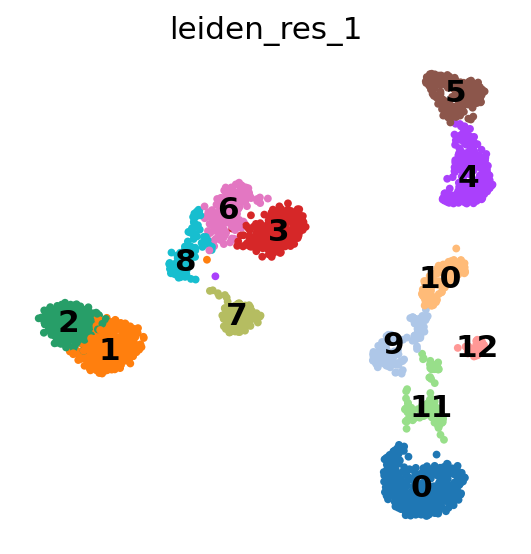

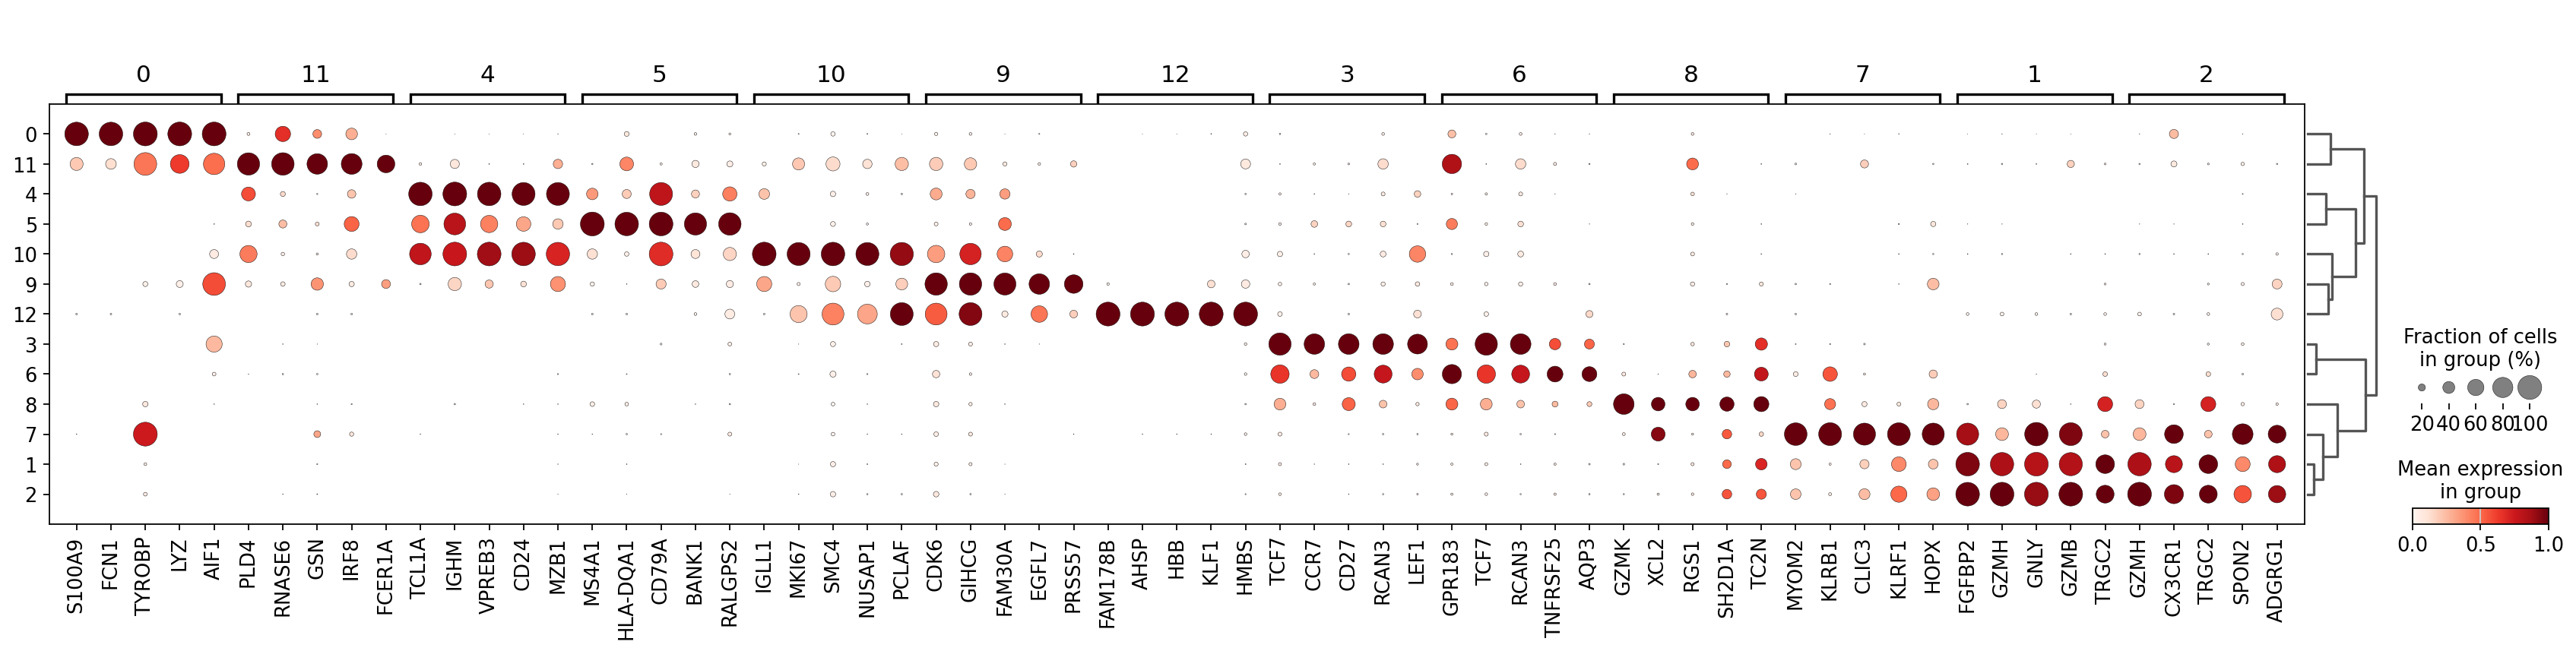

In [5]:
output = run_pipeline(adata,adata_raw,normalization_method='scran',min_in_group_fraction=0.2,max_out_group_fraction=0.2)